# 04 — Sequential Deep Learning (LSTM / GRU Family)
## SOH & RUL Prediction from Cycle-Level Sequences

**Architectures:**
1. Vanilla LSTM — 2-layer, hidden=128, dropout=0.2
2. Bidirectional LSTM — 2-layer
3. GRU — 2-layer
4. Stacked LSTM with Additive Attention — 3-layer

**Training:** Adam + CosineAnnealingLR, MAE loss, EarlyStopping (patience=20), gradient clipping.

**Uncertainty:** MC Dropout (50 forward passes) for 95% confidence intervals.

**Input:** Sliding windows of 32 cycles × 12 features → SOH prediction

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from src.models.deep.lstm import (
    VanillaLSTM, BidirectionalLSTM, GRUModel, AttentionLSTM,
    train_loop, mc_dropout_predict,
)
from src.data.preprocessing import group_battery_split, fit_and_save_scaler, load_scaler
from src.evaluation.metrics import regression_metrics, tolerance_accuracy, build_summary_table
from src.utils.plotting import (
    plot_training_curves, plot_actual_vs_predicted, plot_residuals,
    plot_model_comparison_bars, save_fig,
)
from src.utils.config import (
    ARTIFACTS_DIR, FIGURES_DIR, MODELS_DIR,
    get_version_paths, ensure_version_dirs,
    WINDOW_SIZE, BATCH_SIZE, MAX_EPOCHS, EARLY_STOP_PATIENCE,
    LSTM_HIDDEN, LSTM_LAYERS, LEARNING_RATE, DROPOUT, MC_DROPOUT_SAMPLES,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
plt.style.use("seaborn-v0_8-whitegrid")

# v2 paths
v2 = get_version_paths('v2')
ensure_version_dirs('v2')

Device: cuda
PyTorch: 2.6.0+cu124


## 1. Load Sequence Data

In [2]:
data = np.load(str(ARTIFACTS_DIR / "battery_sequences.npz"), allow_pickle=True)
X_multi = data["X_multi"]    # (N, 32, n_features)
y_multi = data["y_multi"]    # (N,) — SOH target
bids = data["bids_multi"]    # battery IDs

print(f"Multi-feature sequences: X={X_multi.shape}, y={y_multi.shape}")
print(f"Features per timestep: {X_multi.shape[2]}")
print(f"Unique batteries: {np.unique(bids)}")

# ── v2: intra-battery chronological split ──
# For each battery, first 80% of sequences → train, last 20% → test
train_idx, test_idx = [], []
for bid in np.unique(bids):
    idxs = np.where(bids == bid)[0]
    n = len(idxs)
    cut = int(0.8 * n)
    train_idx.extend(idxs[:cut].tolist())
    test_idx.extend(idxs[cut:].tolist())

train_idx = np.array(train_idx)
test_idx = np.array(test_idx)

X_train, y_train = X_multi[train_idx], y_multi[train_idx]
X_test, y_test = X_multi[test_idx], y_multi[test_idx]
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Batteries in both: {len(np.unique(bids))}")

# Normalize features (per feature, across all timesteps)
from sklearn.preprocessing import StandardScaler
n_samples, seq_len, n_feat = X_train.shape
X_train_flat = X_train.reshape(-1, n_feat)
scaler = StandardScaler().fit(X_train_flat)
X_train = scaler.transform(X_train.reshape(-1, n_feat)).reshape(n_samples, seq_len, n_feat)
X_test = scaler.transform(X_test.reshape(-1, n_feat)).reshape(X_test.shape[0], seq_len, n_feat)

# To tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
print("Data loaders ready.")

Multi-feature sequences: X=(1734, 32, 12), y=(1734,)
Features per timestep: 12
Unique batteries: ['B0005' 'B0006' 'B0007' 'B0018' 'B0029' 'B0030' 'B0031' 'B0032' 'B0033'
 'B0034' 'B0036' 'B0038' 'B0039' 'B0040' 'B0041' 'B0042' 'B0043' 'B0044'
 'B0045' 'B0046' 'B0047' 'B0048' 'B0053' 'B0054' 'B0055' 'B0056']
Train: 1444 | Test: 290
Data loaders ready.


## 2. Train All Models

In [3]:
input_dim = n_feat
models_config = {
    "Vanilla LSTM": VanillaLSTM(input_dim, LSTM_HIDDEN, LSTM_LAYERS, DROPOUT),
    "Bidirectional LSTM": BidirectionalLSTM(input_dim, LSTM_HIDDEN, LSTM_LAYERS, DROPOUT),
    "GRU": GRUModel(input_dim, LSTM_HIDDEN, LSTM_LAYERS, DROPOUT),
    "Attention LSTM": AttentionLSTM(input_dim, LSTM_HIDDEN, 3, DROPOUT),
}

all_results = {}
all_histories = {}

for name, model in models_config.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    history = train_loop(
        model, train_loader, val_loader,
        max_epochs=MAX_EPOCHS, lr=LEARNING_RATE,
        patience=EARLY_STOP_PATIENCE, device=device, grad_clip=1.0,
    )
    all_histories[name] = history
    print(f"Best epoch: {history['best_epoch']} / {history['epochs_trained']}")
    
    # Evaluate
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_t.to(device)).cpu().numpy()
    
    metrics = regression_metrics(y_test, y_pred)
    metrics["tolerance_acc_2pct"] = tolerance_accuracy(y_test, y_pred, 2.0)
    all_results[name] = metrics
    print(f"MAE: {metrics['MAE']:.4f} | R²: {metrics['R2']:.4f} | Tol.Acc: {metrics['tolerance_acc_2pct']:.2%}")
    
    # Save checkpoint
    torch.save(model.state_dict(), str(v2["models_deep"] / f"{name.lower().replace(' ', '_')}.pt"))


Training: Vanilla LSTM
Parameters: 204,929


Best epoch: 22 / 42
MAE: 10.5614 | R²: 0.5771 | Tol.Acc: 15.86%

Training: Bidirectional LSTM
Parameters: 540,929


Best epoch: 9 / 29
MAE: 11.1349 | R²: 0.5463 | Tol.Acc: 10.69%

Training: GRU
Parameters: 153,729


Best epoch: 28 / 48
MAE: 9.2758 | R²: 0.6349 | Tol.Acc: 19.31%

Training: Attention LSTM
Parameters: 361,729


Best epoch: 7 / 27
MAE: 14.1813 | R²: 0.2184 | Tol.Acc: 15.86%


## 3. Training Curves

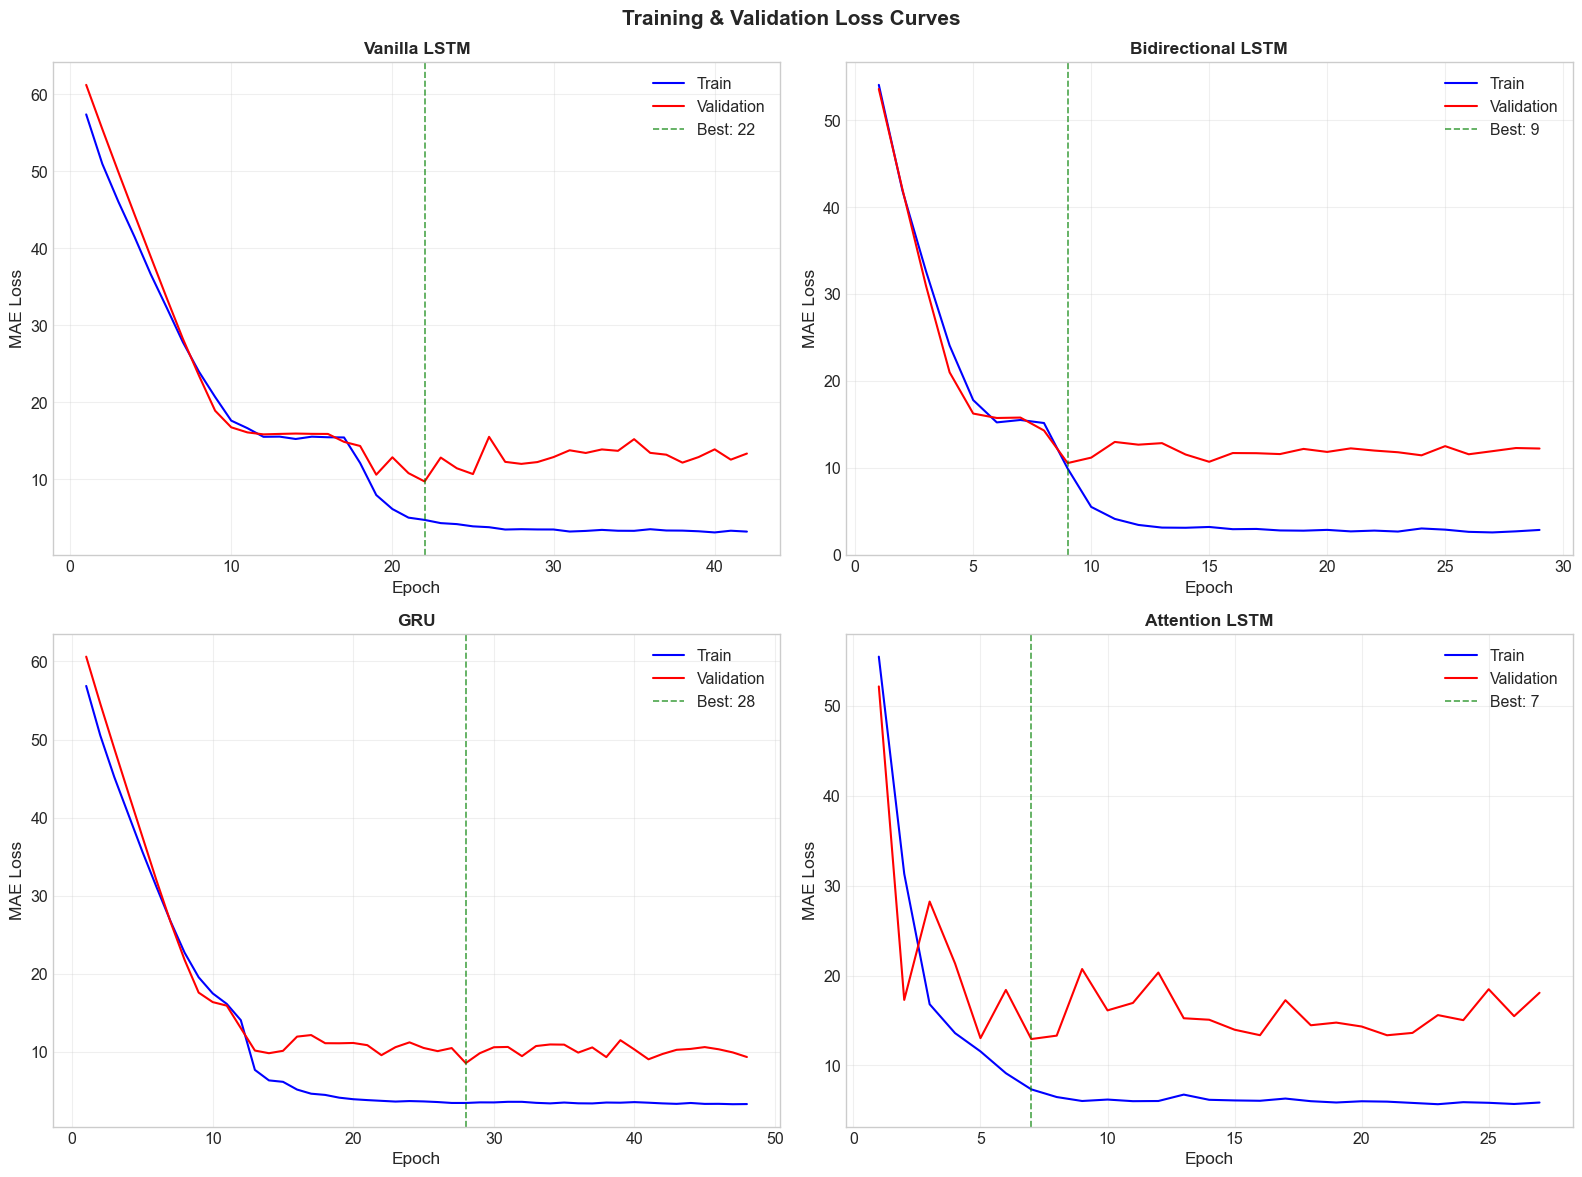

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, (name, hist) in zip(axes.flat, all_histories.items()):
    epochs = range(1, len(hist["train_losses"]) + 1)
    ax.plot(epochs, hist["train_losses"], "b-", linewidth=1.5, label="Train")
    ax.plot(epochs, hist["val_losses"], "r-", linewidth=1.5, label="Validation")
    ax.axvline(x=hist["best_epoch"], color="green", linestyle="--", alpha=0.7, label=f"Best: {hist['best_epoch']}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE Loss")
    ax.set_title(name, fontweight="bold")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Training & Validation Loss Curves", fontsize=15, fontweight="bold")
plt.tight_layout()
save_fig(fig, "v2_lstm_training_curves")
plt.show()

## 4. MC Dropout Uncertainty Estimation

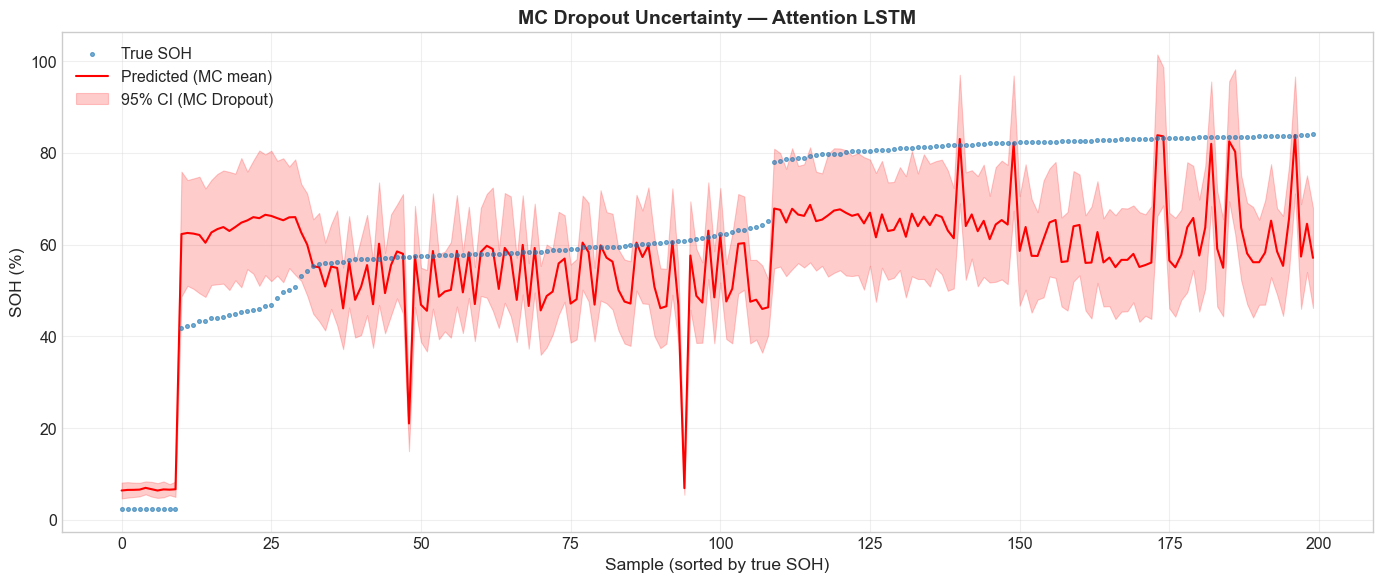

In [5]:
# Use the Attention LSTM for uncertainty
attn_model = models_config["Attention LSTM"].to(device)
mean_pred, std_pred = mc_dropout_predict(attn_model, X_test_t.to(device), n_samples=MC_DROPOUT_SAMPLES)
mean_pred = mean_pred.detach().cpu().numpy()
std_pred = std_pred.detach().cpu().numpy()

# 95% CI
ci_lower = mean_pred - 1.96 * std_pred
ci_upper = mean_pred + 1.96 * std_pred

# Plot a subset (first 200 test samples sorted by true SOH)
sort_idx = np.argsort(y_test)[:200]
fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(range(len(sort_idx)), y_test[sort_idx], s=8, alpha=0.6, label="True SOH", zorder=3)
ax.plot(range(len(sort_idx)), mean_pred[sort_idx], "r-", linewidth=1.5, label="Predicted (MC mean)", zorder=2)
ax.fill_between(range(len(sort_idx)), ci_lower[sort_idx], ci_upper[sort_idx],
                alpha=0.2, color="red", label="95% CI (MC Dropout)")
ax.set_xlabel("Sample (sorted by true SOH)")
ax.set_ylabel("SOH (%)")
ax.set_title("MC Dropout Uncertainty — Attention LSTM", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
save_fig(fig, "v2_mc_dropout_uncertainty_lstm")
plt.show()

## 5. Actual vs Predicted & Residuals

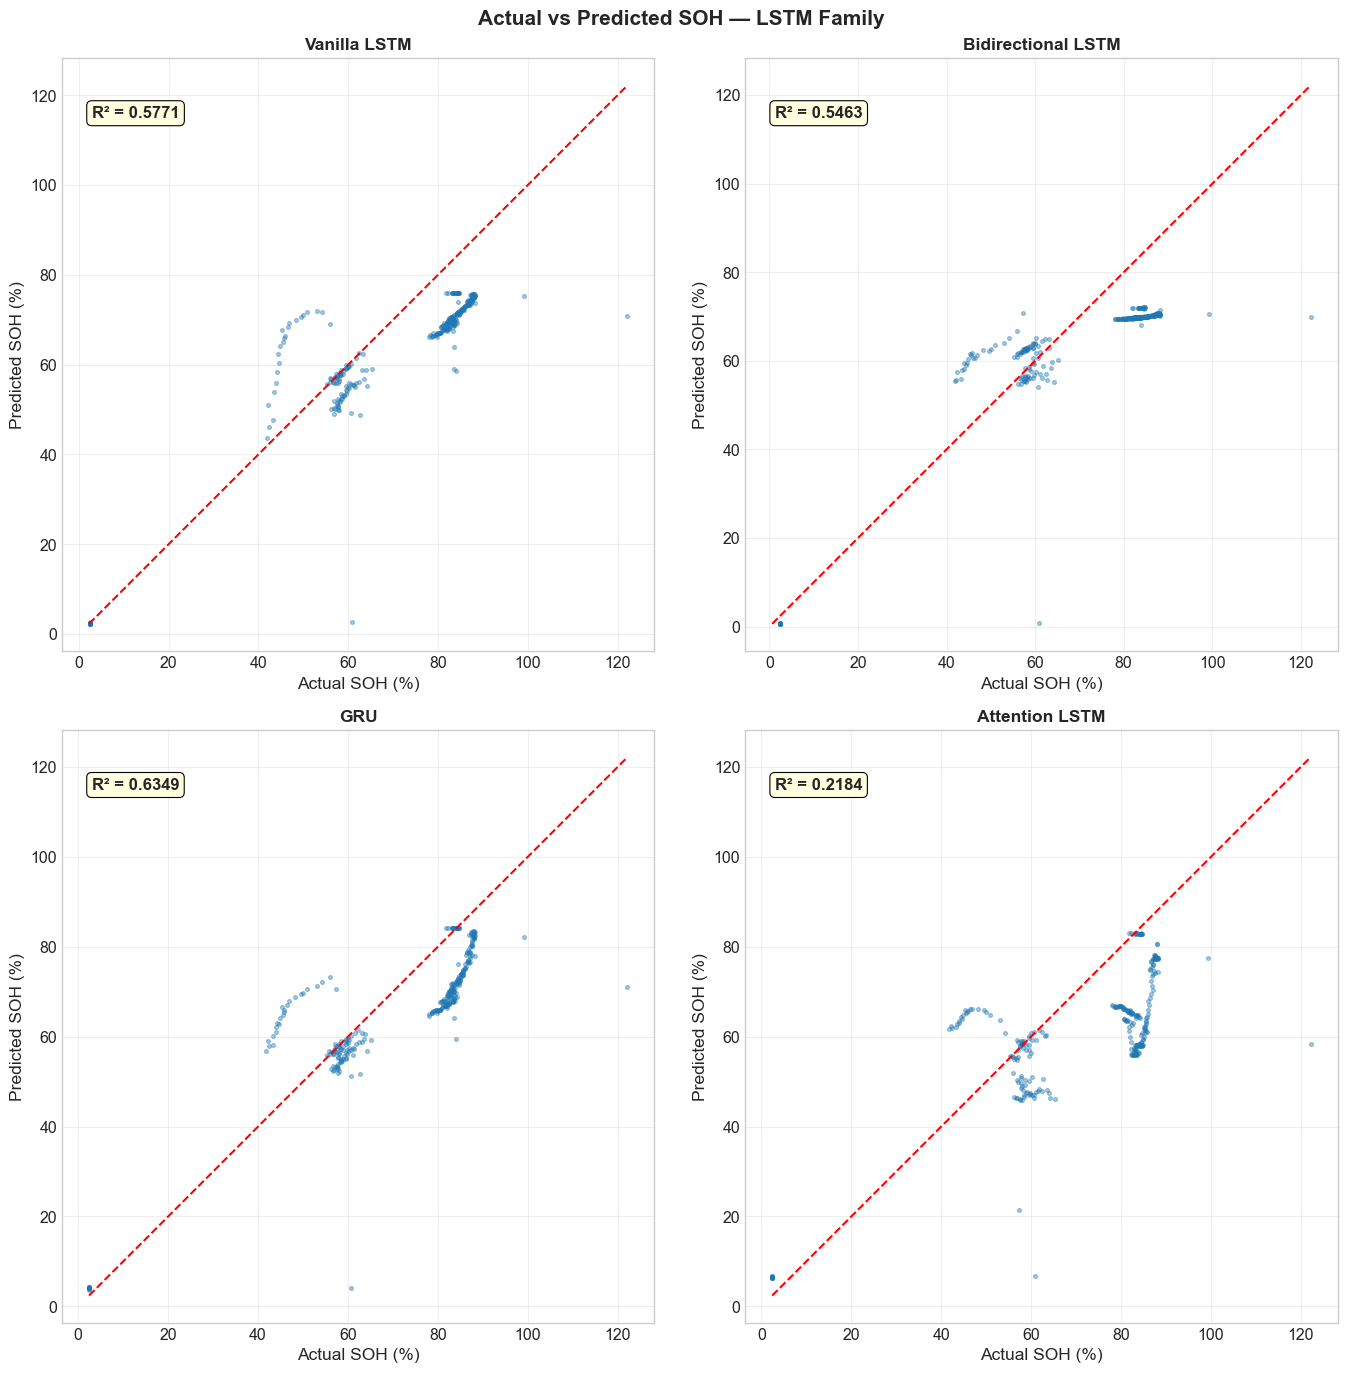

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, (name, model) in zip(axes.flat, models_config.items()):
    model.eval()
    with torch.no_grad():
        y_pred = model.to(device)(X_test_t.to(device)).cpu().numpy()
    ax.scatter(y_test, y_pred, s=8, alpha=0.4)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1.5)
    from sklearn.metrics import r2_score
    r2 = r2_score(y_test, y_pred)
    ax.annotate(f"R² = {r2:.4f}", xy=(0.05, 0.9), xycoords="axes fraction",
                fontsize=12, fontweight="bold", bbox=dict(boxstyle="round", facecolor="lightyellow"))
    ax.set_xlabel("Actual SOH (%)")
    ax.set_ylabel("Predicted SOH (%)")
    ax.set_title(name, fontweight="bold")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

plt.suptitle("Actual vs Predicted SOH — LSTM Family", fontsize=15, fontweight="bold")
plt.tight_layout()
save_fig(fig, "v2_lstm_actual_vs_predicted")
plt.show()

## 6. Model Comparison Summary

In [7]:
summary = build_summary_table(all_results)
summary = summary.sort_values("R2", ascending=False)
display(summary.round(4))
summary.to_csv(v2["results"] / "v2_lstm_soh_results.csv")
print("Saved to v2 results")
print(f"\nBest model: {summary.index[0]} with R² = {summary.iloc[0]['R2']:.4f}")

,MAE,MSE,RMSE,R2,MAPE,tolerance_acc_2pct
model,,,,,,
GRU,9.2758,134.6546,11.6041,0.6349,15.2485,0.1931
Vanilla LSTM,10.5614,155.9577,12.4883,0.5771,14.3751,0.1586
Bidirectional LSTM,11.1349,167.3344,12.9358,0.5463,17.1246,0.1069
Attention LSTM,14.1813,288.2399,16.9776,0.2184,24.8279,0.1586


Saved to artifacts/lstm_soh_results.csv

Best model: GRU with R² = 0.6349
